In [6]:
import scipy.io as sio
import pandas as pd
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
mat_file_path = "/juice2/scr2/kelvinkn/other_work/edwards/ptb/converted_ptxbl_records500/00000/00002_hr.mat"

In [42]:
hea_file_path = "/juice2/scr2/kelvinkn/other_work/edwards/ptb/converted_ptxbl_records500/00000/00002_hr.hea"
# Read the hea file at the specified path
with open(hea_file_path, 'r') as file:
    hea_content = file.readlines()
print(hea_content)

['00002_hr 12 500 5000 12:55:37 14/11/1984\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 -15 -17863 0 I\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 120 -17160 0 II\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 135 734 0 III\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 -53 17529 0 AVR\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 -75 -9284 0 AVL\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 127 -8311 0 AVF\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 -105 22419 0 V1\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 70 -2478 0 V2\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 115 -5164 0 V3\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 160 4753 0 V4\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 60 15615 0 V5\n', '00002_hr.mat 16x1+192 1000.0(0)/mV 16 0 65 1959 0 V6\n', '# Age: 19\n', '# Sex: Male\n', '# Chagas label: False\n', '# Source: PTB-XL\n']


In [37]:
mat_data = sio.loadmat(mat_file_path)

In [38]:
ecg_signals = mat_data['val']
ecg_signals

array([[-115, -115, -115, ...,  210,  210,  210],
       [ -50,  -50,  -50, ...,  205,  205,  205],
       [  65,   65,   65, ...,   -5,   -5,   -5],
       ...,
       [ -35,  -35,  -35, ...,  185,  185,  185],
       [ -35,  -35,  -35, ...,  170,  170,  170],
       [ -75,  -75,  -75, ...,  180,  180,  180]], dtype=int16)

In [29]:
sampling_rate = 400

Processing Lead: I


<Figure size 1000x400 with 0 Axes>

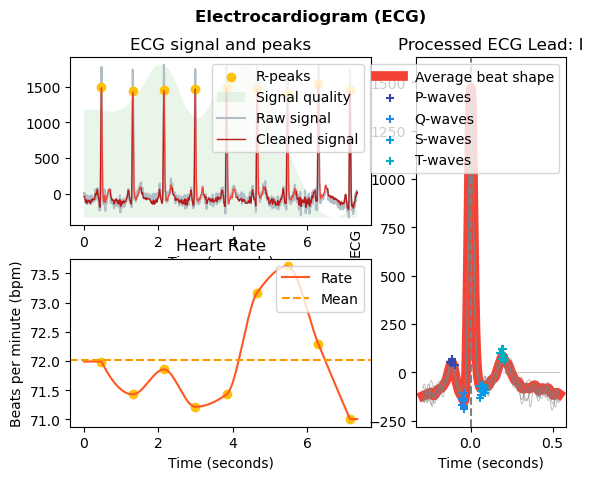

Processing Lead: II


<Figure size 1000x400 with 0 Axes>

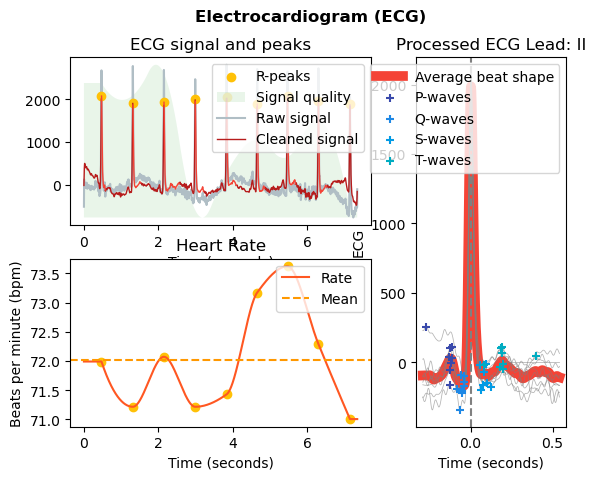

Processing Lead: III


<Figure size 1000x400 with 0 Axes>

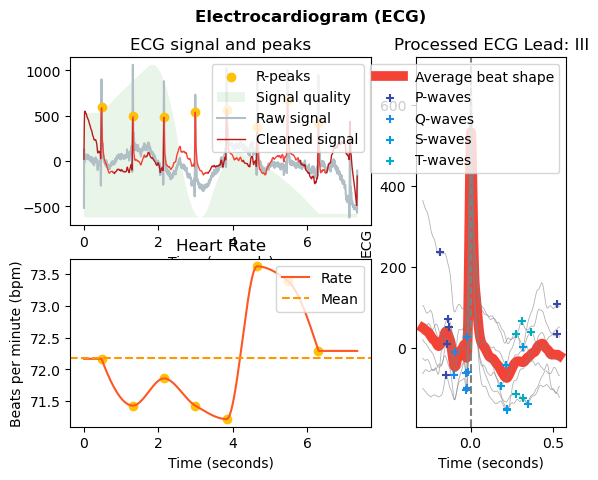

Processing Lead: aVR


<Figure size 1000x400 with 0 Axes>

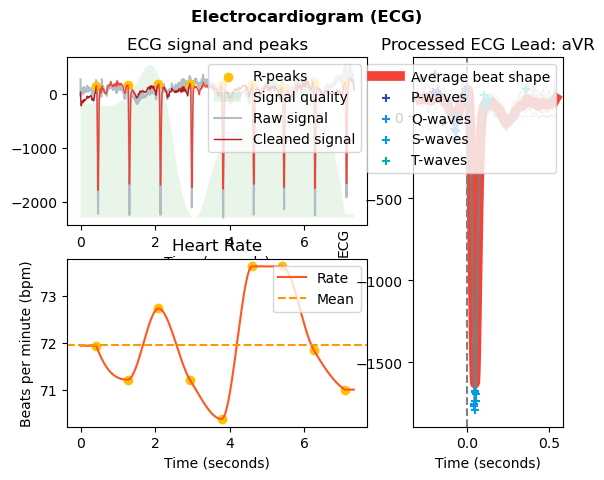

Processing Lead: aVL


<Figure size 1000x400 with 0 Axes>

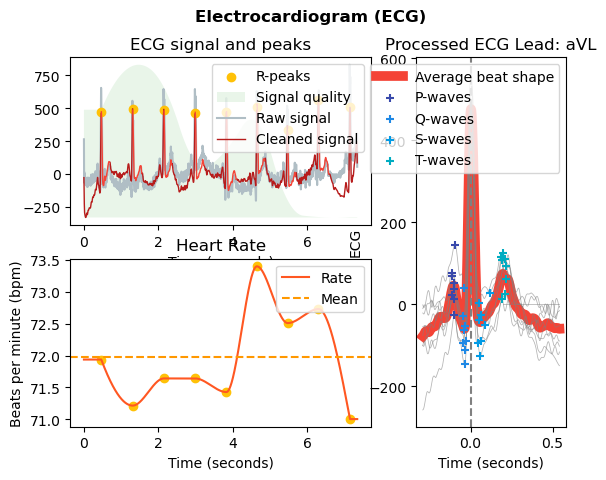

Processing Lead: aVF


<Figure size 1000x400 with 0 Axes>

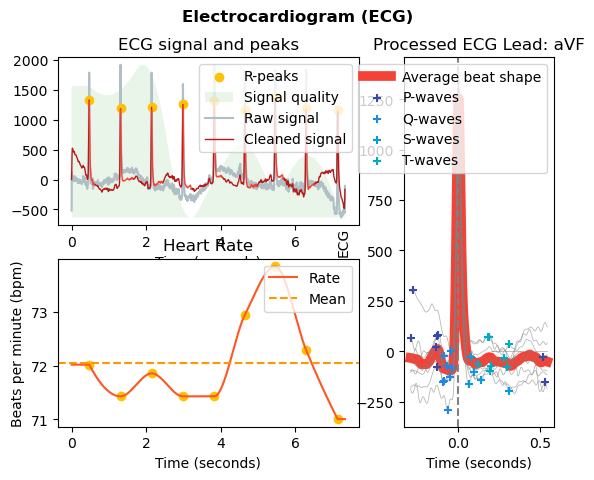

Processing Lead: V1


<Figure size 1000x400 with 0 Axes>

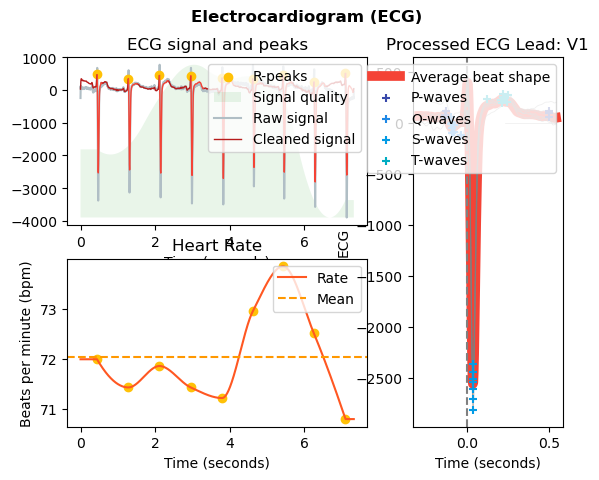

Processing Lead: V2


<Figure size 1000x400 with 0 Axes>

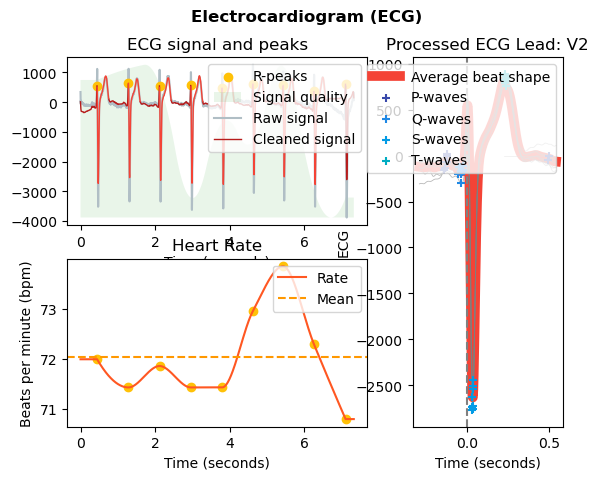

Processing Lead: V3


<Figure size 1000x400 with 0 Axes>

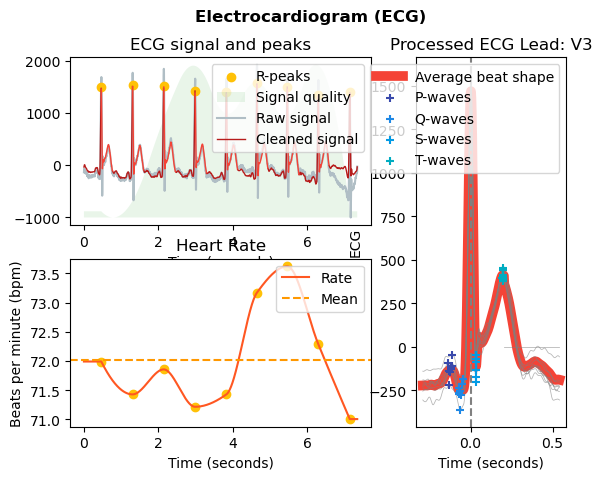

Processing Lead: V4


<Figure size 1000x400 with 0 Axes>

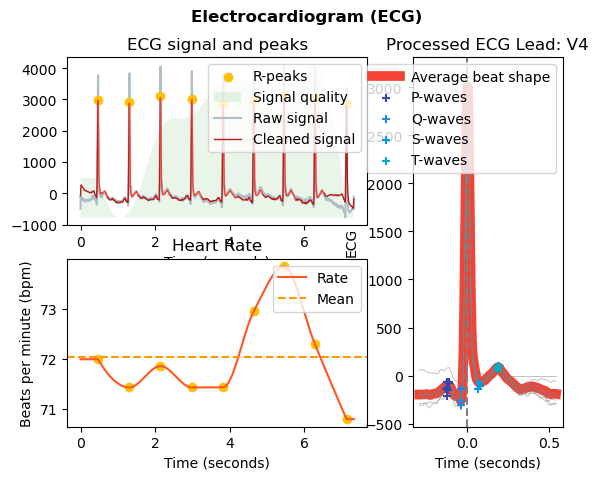

Processing Lead: V5


<Figure size 1000x400 with 0 Axes>

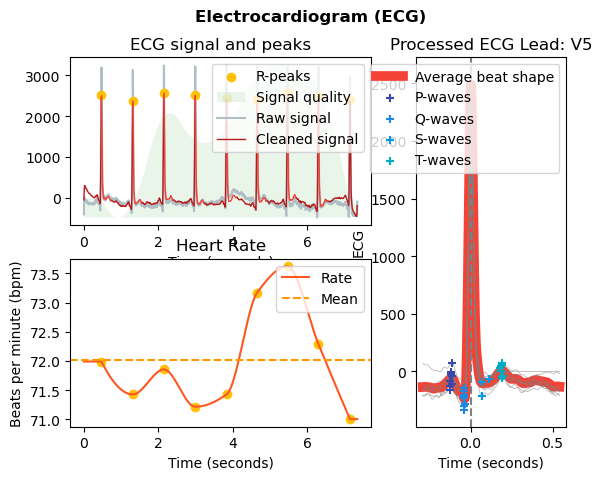

Processing Lead: V6


<Figure size 1000x400 with 0 Axes>

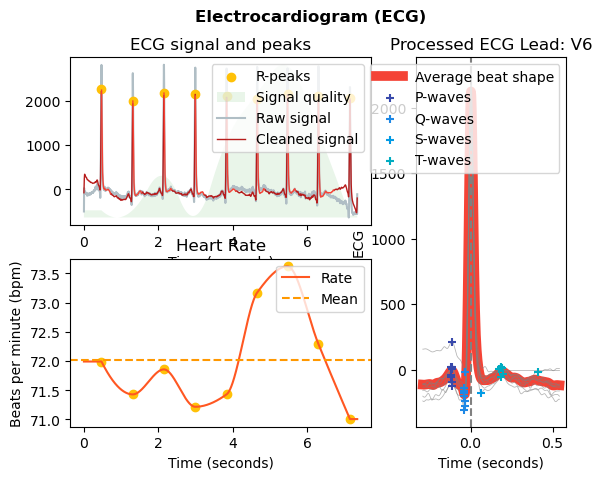


Mean Heart Rates per Lead:
{'I': 72.02437577773783, 'II': 72.01941781918265, 'III': 72.17895464996235, 'aVR': 71.95049077766194, 'aVL': 71.9805160029237, 'aVF': 72.05088875096034, 'V1': 72.03282350466246, 'V2': 72.02896720125656, 'V3': 72.02370428219244, 'V4': 72.03303857463035, 'V5': 72.02437577773783, 'V6': 72.02437577773783}


In [34]:
# Assuming ecg_signals is a NumPy array with shape (num_samples, 12)
# If it's (12, num_samples), transpose it: ecg_signals = ecg_signals.T

all_processed_data = {}
all_info = {}

# Define standard 12-lead names for easier interpretation
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Ensure the number of leads matches your data
if ecg_signals.shape[0] != len(lead_names):
    print(f"Warning: Number of leads in data ({ecg_signals.shape[0]}) does not match standard 12-lead names ({len(lead_names)}).")
    # You might need to adjust lead_names or how you select leads

for i, lead_name in enumerate(lead_names):
    print(f"Processing Lead: {lead_name}")
    lead_data = ecg_signals[i] # Select the current lead

    # Process the single lead
    processed_signals, info = nk.ecg_process(lead_data, sampling_rate=sampling_rate, method="neurokit")

    all_processed_data[lead_name] = processed_signals
    all_info[lead_name] = info

    #Optional: Plot a short segment of the processed lead
    plt.figure(figsize=(10, 4))
    nk.ecg_plot(processed_signals, info)
    plt.title(f"Processed ECG Lead: {lead_name}")
    plt.show()

# Now you have 'all_processed_data' and 'all_info' dictionaries.
# Each key in these dictionaries corresponds to a lead name,
# and the value contains the processed DataFrame/info dictionary for that lead.

# Example: Accessing HRV for Lead II
# if 'II' in all_info:
#     rr_intervals = all_info['II']['ECG_R_Peaks']
#     # If rr_intervals are indices, convert to actual RR intervals for HRV
#     # NeuroKit's hrv function directly takes R-peak indices or RR intervals
#     hrv_features_lead_II = nk.hrv(rr_intervals, sampling_rate=sampling_rate)
#     print("\nHRV Features for Lead II:")
#     print(hrv_features_lead_II)

# Example: Get mean heart rate for all leads (where available)
mean_heart_rates = {}
for lead, signals_df in all_processed_data.items():
    if 'ECG_Rate' in signals_df.columns:
        mean_heart_rates[lead] = signals_df['ECG_Rate'].mean()
print("\nMean Heart Rates per Lead:")
print(mean_heart_rates)

In [17]:
len(ecg_signals)

12

In [19]:
ecg_signals.shape

(12, 2934)

## Note that even though it says 0 for peaks, what it actually means is that the sample with peaks will have value 1 for the type of peak they are, else, they are 0. Meaning 0 is a verry common value, but you can see in the above graphs that there are actually peaks

In [35]:
all_processed_data['I']

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,0,-37.873718,71.991001,0.692999,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,-9,-37.512471,71.991001,0.692999,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,-6,-37.291842,71.991001,0.692999,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,2,-37.321201,71.991001,0.692999,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,0,-37.944294,71.991001,0.692999,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2929,25,24.220811,71.005917,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2930,39,22.305659,71.005917,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2931,34,17.982682,71.005917,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2932,10,11.799202,71.005917,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


In [36]:
all_info['I']

{'method_peaks': 'neurokit',
 'method_fixpeaks': 'None',
 'ECG_R_Peaks': array([ 188,  524,  858, 1195, 1531, 1859, 2185, 2517, 2855]),
 'ECG_R_Peaks_Uncorrected': array([ 188,  524,  858, 1195, 1531, 1859, 2185, 2517, 2855]),
 'ECG_fixpeaks_ectopic': [],
 'ECG_fixpeaks_missed': [],
 'ECG_fixpeaks_extra': [],
 'ECG_fixpeaks_longshort': [],
 'ECG_fixpeaks_method': 'kubios',
 'ECG_fixpeaks_rr': array([0.8334375, 0.84     , 0.835    , 0.8425   , 0.84     , 0.82     ,
        0.815    , 0.83     , 0.845    ]),
 'ECG_fixpeaks_drrs': array([ 0.05558894,  0.25240385, -0.19230769,  0.28846154, -0.09615385,
        -0.76923077, -0.19230769,  0.57692308,  0.57692308]),
 'ECG_fixpeaks_mrrs': array([-0.625     ,  0.38461538,  0.06009615,  0.57692308,  0.38461538,
        -2.30769231, -3.46153846, -0.76923077,  0.76923077]),
 'ECG_fixpeaks_s12': array([ 0.25240385,  0.05558894,  0.25240385, -0.09615385, -0.76923077,
        -0.19230769, -0.76923077,  0.57692308,  0.57692308]),
 'ECG_fixpeaks_s22': 

In [24]:
ecg_signals[13]

IndexError: index 13 is out of bounds for axis 0 with size 12

# Experimenting with Getting a window around a heart event

In [21]:
import numpy as np
import pandas as pd
import neurokit2 as nk

def calculate_ecg_features(ecg_signal, sampling_rate):
    """
    Processes a single-lead ECG signal using NeuroKit2 and calculates aggregated features.

    This function addresses common issues like missing delineations by carefully
    handling potential KeyErrors and NaN values, preventing runtime warnings and crashes.

    Args:
        ecg_signal (array): The raw ECG signal as a 1D NumPy array.
        sampling_rate (int): The sampling rate of the ECG signal (in Hz).

    Returns:
        dict: A dictionary containing the calculated aggregated features.
    """

    # --- Step 1: Process the ECG Signal using NeuroKit2 ---
    try:
        signals, info = nk.ecg_process(ecg_signal, sampling_rate=sampling_rate)
        r_peaks = info["ECG_R_Peaks"]
        # Exit if no R-peaks were found, as delineation is not possible
        if len(r_peaks) == 0:
            print("Warning: No R-peaks found in the signal. Cannot calculate features.")
            return {}
    except Exception as e:
        print(f"An error occurred during NeuroKit2 processing: {e}")
        return None

    # --- Step 2: Delineate Waveforms ---
    # The `dwt` method is generally robust, but may still fail on noisy signals.
    try:
        _, waves = nk.ecg_delineate(ecg_signal, r_peaks, sampling_rate=sampling_rate, method="dwt")
    except Exception as e:
        print(f"An error occurred during ECG delineation: {e}. Cannot calculate features.")
        # Return an empty dictionary if delineation fails
        return {}


    # --- Step 3: Calculate QRS Duration for Each Beat (Robustly) ---
    # Use .get() to safely access dictionary keys. The 'dwt' method returns the
    # QRS boundaries as 'ECG_R_Onsets' and 'ECG_R_Offsets'.
    qrs_onsets = waves.get('ECG_R_Onsets', [])
    qrs_offsets = waves.get('ECG_R_Offsets', [])

    all_qrs_durations_ms = []
    for onset, offset in zip(qrs_onsets, qrs_offsets):
        if pd.notna(onset) and pd.notna(offset):
            duration_samples = offset - onset
            duration_ms = (duration_samples / sampling_rate) * 1000
            all_qrs_durations_ms.append(duration_ms)

    # --- Step 4: Calculate Pathological Q-Waves (Robustly) ---
    # NOTE: The 'dwt' method does not delineate individual Q and S waves,
    # so we cannot calculate pathological Q-waves with this specific method.
    # This section is kept for completeness if a different delineation method is used.
    q_onsets = waves.get('ECG_Q_Onsets', [])
    s_onsets = waves.get('ECG_S_Onsets', []) # Using S-onset as a proxy for Q-offset
    
    pathological_q_waves_count = 0
    valid_q_waves = 0
    if q_onsets and s_onsets:
        for q_onset, s_onset in zip(q_onsets, s_onsets):
            if pd.notna(q_onset) and pd.notna(s_onset):
                valid_q_waves += 1
                q_duration_ms = ((s_onset - q_onset) / sampling_rate) * 1000
                if q_duration_ms > 40:
                    pathological_q_waves_count += 1
    
    percentage_path_q = (pathological_q_waves_count / valid_q_waves * 100) if valid_q_waves > 0 else 0

    # --- Step 5: Calculate ST Segment Deviation (Robustly) ---
    t_onsets = waves.get('ECG_T_Onsets', [])
    all_st_deviations = []

    # Use qrs_onsets which was safely retrieved earlier
    for qrs_onset, t_onset in zip(qrs_onsets, t_onsets):
      if pd.notna(qrs_onset) and pd.notna(t_onset) and int(qrs_onset) < len(ecg_signal) and int(t_onset) < len(ecg_signal):
          isoelectric_level = ecg_signal[int(qrs_onset)]
          j_point_level = ecg_signal[int(t_onset)]
          st_deviation_mv = (j_point_level - isoelectric_level)
          all_st_deviations.append(st_deviation_mv)

    # Convert lists to numpy arrays for safe statistical calculation
    all_qrs_durations_ms = np.array(all_qrs_durations_ms)
    all_st_deviations = np.array(all_st_deviations)

    # --- Step 6: Aggregate Features and Handle Potential Empty Slices ---
    features = {
        "Mean QRS Duration (ms)": np.mean(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        "Max QRS Duration (ms)": np.max(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        "Std Dev QRS Duration (ms)": np.std(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        "Number of Pathological Q Waves": pathological_q_waves_count,
        "Percentage of Pathological Q Waves (%)": percentage_path_q,
        "Mean ST Deviation (mV)": np.mean(all_st_deviations) if len(all_st_deviations) > 0 else np.nan,
        "Max ST Elevation (mV)": np.max(all_st_deviations[all_st_deviations > 0]) if len(all_st_deviations[all_st_deviations > 0]) > 0 else 0,
        "Max ST Depression (mV)": np.min(all_st_deviations[all_st_deviations < 0]) if len(all_st_deviations[all_st_deviations < 0]) > 0 else 0,
    }

    return features

# --- Main Execution: Simulate ECG and Calculate Features ---

# Simulation parameters
sampling_rate = 1000  # Hz
duration = 15  # seconds
heart_rate = 70 # beats per minute

# Generate a synthetic ECG signal
ecg_simulated = nk.ecg_simulate(duration=duration, sampling_rate=sampling_rate, heart_rate=heart_rate, random_state=42)

# Calculate features on the simulated signal
aggregated_features = calculate_ecg_features(ecg_simulated, sampling_rate)

# --- Print Results ---
if aggregated_features:
    print("--- Aggregated ECG Features (from simulated data) ---")
    for key, value in aggregated_features.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")
    print("\n--- QRS Axis Calculation Note ---")
    print("QRS axis calculation requires simultaneous data from Leads I and aVF and cannot be calculated from a single-lead signal.")


--- Aggregated ECG Features (from simulated data) ---
Mean QRS Duration (ms): 141.0000
Max QRS Duration (ms): 146.0000
Std Dev QRS Duration (ms): 3.0414
Number of Pathological Q Waves: 0
Percentage of Pathological Q Waves (%): 0
Mean ST Deviation (mV): 0.0408
Max ST Elevation (mV): 0.1386
Max ST Depression (mV): -0.3153

--- QRS Axis Calculation Note ---
QRS axis calculation requires simultaneous data from Leads I and aVF and cannot be calculated from a single-lead signal.


In [26]:
calculate_ecg_features(ecg_signals[5], 400)

{'Mean QRS Duration (ms)': 107.1875,
 'Max QRS Duration (ms)': 137.5,
 'Std Dev QRS Duration (ms)': 18.176113274019833,
 'Number of Pathological Q Waves': 0,
 'Percentage of Pathological Q Waves (%)': 0,
 'Mean ST Deviation (mV)': 25.0,
 'Max ST Elevation (mV)': 240,
 'Max ST Depression (mV)': -153}

In [43]:
# dictionary for storing all features for each lead
# Loop through each lead in the ECG signals
features_dict = {}
for i in range(len(ecg_signals)):
    print(f"Processing Lead {i+1}")
    features = calculate_ecg_features(ecg_signals[i], 400)
    if features:  # Only store features if the calculation was successful
        features_dict[f"Lead_{i+1}"] = features
    else:
        print(f"Skipping Lead {i+1} due to processing error.")
    

Processing Lead 1
Processing Lead 2
Processing Lead 3
Processing Lead 4
Processing Lead 5
Processing Lead 6
Processing Lead 7
Processing Lead 8
Processing Lead 9
Processing Lead 10
Processing Lead 11
Processing Lead 12


In [44]:
# Get the max qrs duration across all leads
max_qrs_duration = max(features['Mean QRS Duration (ms)'] for features in features_dict.values())
print(f"Max QRS Duration across all leads: {max_qrs_duration:.2f} ms")

Max QRS Duration across all leads: 247.22 ms


In [45]:
import numpy as np

# Assume 'features_dict_numeric' is your original dictionary indexed by numbers (0-11)
# For demonstration purposes, let's create a sample numeric dictionary.
# In your actual use case, you would use your own 'features_dict'.
features_dict_numeric = {
    i: {'Max ST Elevation (mV)': np.random.uniform(0, 0.5), 'Max ST Depression (mV)': np.random.uniform(-0.3, 0)}
    for i in range(12)
}

# Standard 12-lead ECG ordering
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Create the new 'features_dict' with lead names as keys
features_dict = {lead_names[i]: features_dict_numeric[i] for i in range(len(lead_names))}

# Your original code for calculating ST segment elevation and depression will now work correctly.

# Define the contiguous leads
inferior_leads = ['II', 'III', 'aVF']
lateral_leads = ['I', 'aVL', 'V5', 'V6']
anterior_leads = ['V3', 'V4']
septal_leads = ['V1', 'V2']

# Calculate ST segment elevation and depression for each lead group
inferior_st_elevation = [features_dict[lead]['Max ST Elevation (mV)'] for lead in inferior_leads if lead in features_dict]
inferior_st_depression = [features_dict[lead]['Max ST Depression (mV)'] for lead in inferior_leads if lead in features_dict]

lateral_st_elevation = [features_dict[lead]['Max ST Elevation (mV)'] for lead in lateral_leads if lead in features_dict]
lateral_st_depression = [features_dict[lead]['Max ST Depression (mV)'] for lead in lateral_leads if lead in features_dict]

anterior_st_elevation = [features_dict[lead]['Max ST Elevation (mV)'] for lead in anterior_leads if lead in features_dict]
anterior_st_depression = [features_dict[lead]['Max ST Depression (mV)'] for lead in anterior_leads if lead in features_dict]

septal_st_elevation = [features_dict[lead]['Max ST Elevation (mV)'] for lead in septal_leads if lead in features_dict]
septal_st_depression = [features_dict[lead]['Max ST Depression (mV)'] for lead in septal_leads if lead in features_dict]

# Print the results
print("Inferior Leads ST Segment Elevation and Depression:")
print(f"  Elevation: {np.mean(inferior_st_elevation):.2f} mV")
print(f"  Depression: {np.mean(inferior_st_depression):.2f} mV")

print("\nLateral Leads ST Segment Elevation and Depression:")
print(f"  Elevation: {np.mean(lateral_st_elevation):.2f} mV")
print(f"  Depression: {np.mean(lateral_st_depression):.2f} mV")

print("\nAnterior Leads ST Segment Elevation and Depression:")
print(f"  Elevation: {np.mean(anterior_st_elevation):.2f} mV")
print(f"  Depression: {np.mean(anterior_st_depression):.2f} mV")

print("\nSeptal Leads ST Segment Elevation and Depression:")
print(f"  Elevation: {np.mean(septal_st_elevation):.2f} mV")
print(f"  Depression: {np.mean(septal_st_depression):.2f} mV")

Inferior Leads ST Segment Elevation and Depression:
  Elevation: 0.16 mV
  Depression: -0.17 mV

Lateral Leads ST Segment Elevation and Depression:
  Elevation: 0.17 mV
  Depression: -0.18 mV

Anterior Leads ST Segment Elevation and Depression:
  Elevation: 0.25 mV
  Depression: -0.06 mV

Septal Leads ST Segment Elevation and Depression:
  Elevation: 0.15 mV
  Depression: -0.10 mV


In [ ]:
len(ecg_signals[])

2934

In [12]:
sampling_rate

1000